In [1]:
tickers = ["IDFCFIRSTB.NS", "ICICIBANK.NS", "AXISBANK.NS"]

In [2]:
import yfinance as yf
import pandas as pd

ratios_data = {}

for t in tickers:
    stock = yf.Ticker(t)
    info = stock.info

    net_income = info.get('netIncomeToCommon')
    total_revenue = info.get('totalRevenue')
    roe = info.get('returnOnEquity')
    roa = info.get('returnOnAssets')
    debt_to_equity = info.get('debtToEquity')

    net_margin = (net_income / total_revenue) if net_income and total_revenue else None

    ratios_data[t] = {
        'ROE (%)': round(roe * 100, 2) if roe else None,
        'ROA (%)': round(roa * 100, 2) if roa else None,
        'Net Margin (%)': round(net_margin * 100, 2) if net_margin else None,
        'Debt/Equity': round(debt_to_equity, 2) if debt_to_equity else None,
    }

df = pd.DataFrame(ratios_data).T
print(df)

               ROE (%)  ROA (%)  Net Margin (%)  Debt/Equity
IDFCFIRSTB.NS      NaN      NaN           32.77          NaN
ICICIBANK.NS     16.07     2.11           27.53          NaN
AXISBANK.NS      13.35     1.54           36.03          NaN


In [3]:
# Run this after step 2 — look for None values
print(df.isnull().sum())

ROE (%)           1
ROA (%)           1
Net Margin (%)    0
Debt/Equity       3
dtype: int64


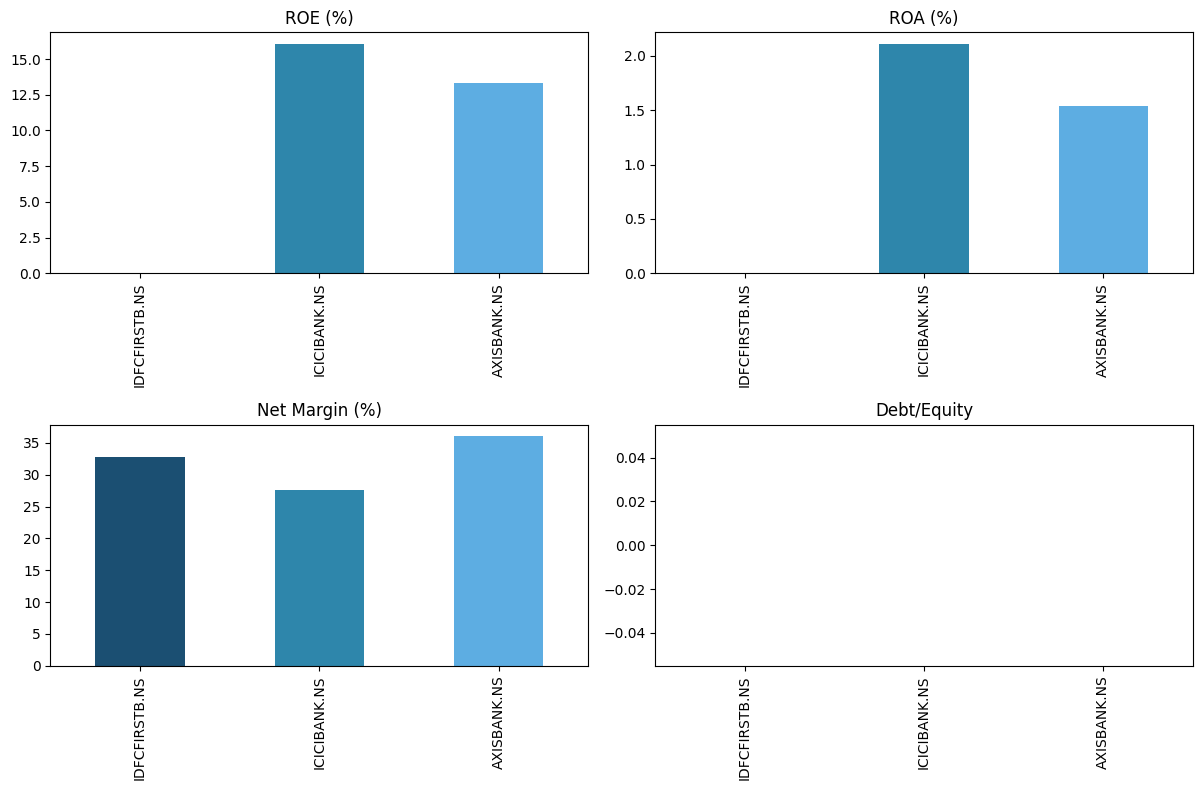

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = df.columns

for ax, metric in zip(axes.flatten(), metrics):
    df[metric].plot(kind='bar', ax=ax, color=['#1B4F72', '#2E86AB', '#5DADE2'])
    ax.set_title(metric)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('bank_ratio_comparison.png')
plt.show()